In [ ]:
# ==============================================================
# STEP 1: INSTALL & IMPORT LIBRARIES
# ==============================================================
# This cell installs and imports all the Python packages needed.
# WHY:
# - yfinance: To download cryptocurrency price data from Yahoo Finance.
# - pandas/numpy: For data manipulation and numerical operations.
# - matplotlib/seaborn: For data visualization.
# - scikit-learn: For preprocessing and basic machine learning.
# - statsmodels: For ARIMA (time series forecasting model).
# - tensorflow/keras: For building the LSTM deep learning model.

!pip install yfinance tensorflow statsmodels seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from statsmodels.tsa.arima.model import ARIMA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


In [ ]:
# ==============================================================
# STEP 2: DOWNLOAD HISTORICAL CRYPTOCURRENCY DATA
# ==============================================================
# WHAT: This section downloads Bitcoin (BTC) and Ethereum (ETH) price data.
# WHY: Real-world historical data is required to train and test forecasting models.
# We use Yahoo Finance (via yfinance) because it provides free, reliable daily price data.

import yfinance as yf

print("Downloading Bitcoin and Ethereum data...")

btc = yf.download('BTC-USD', start='2020-01-01', end='2025-01-01')
eth = yf.download('ETH-USD', start='2020-01-01', end='2025-01-01')

# Keep only key financial columns for modeling
btc = btc[['Open', 'High', 'Low', 'Close', 'Volume']]
eth = eth[['Open', 'High', 'Low', 'Close', 'Volume']]

print("✅ Data successfully downloaded.")
print("\nBitcoin dataset preview:")
btc.head()


/tmp/ipython-input-8886192.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', start='2020-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-8886192.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth = yf.download('ETH-USD', start='2020-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed

✅ Data successfully downloaded.

Bitcoin dataset preview:


Price,Open,High,Low,Close,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7194.892090,7254.330566,7174.944336,7200.174316,18565664997
2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215,20802083465
2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277,28111481032
2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738,18444271275
2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383,19725074095


In [ ]:
# ==============================================================
# STEP 3: DATA PREPROCESSING
# ==============================================================
# WHAT: Clean, transform, and prepare data for machine learning.
# WHY: Models cannot learn properly with missing, unscaled, or undefined target data.

# 1️⃣ Remove missing data to ensure clean training samples
btc.dropna(inplace=True)

# 2️⃣ Create a "Target" column: tomorrow’s closing price
# WHY: This turns the problem into supervised learning — predicting the next day’s price.
btc['Target'] = btc['Close'].shift(-1)
btc.dropna(inplace=True)

# 3️⃣ Scale features so they’re all on the same 0–1 range
# WHY: Prevents features with large numeric ranges (like volume) from dominating smaller ones.
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(btc[['Open', 'High', 'Low', 'Close', 'Volume']])

# 4️⃣ Split features and target variables
X = scaled_features
y = btc['Target'].values

# 5️⃣ Split into training and testing sets (no shuffle because data is sequential)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("✅ Preprocessing complete. Data is clean and scaled.")


✅ Preprocessing complete. Data is clean and scaled.


In [ ]:
# ==============================================================
# STEP 4: BASELINE MODEL - LINEAR REGRESSION
# ==============================================================
# WHAT: Simple model assuming a straight-line relationship between inputs and price.
# WHY: Acts as a baseline for comparison against more complex models.

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Evaluate the Linear Regression model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"✅ Linear Regression completed.")
print(f"MAE: {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")


✅ Linear Regression completed.
MAE: 1344.9043
RMSE: 1879.6534


In [ ]:
# ==============================================================
# STEP 5: STATISTICAL MODEL - ARIMA
# ==============================================================
# WHAT: ARIMA models price as a function of its past values and past forecast errors.
# WHY: Time-series analysis approach that provides a benchmark for sequential forecasting.

train_data = btc['Close'][:-100]
test_data = btc['Close'][-100:]

# (p,d,q) = (5,1,0) chosen as a reasonable starting point.
model = ARIMA(train_data, order=(5, 1, 0))
model_fit = model.fit()

# Forecast over the test period
y_pred_arima = model_fit.forecast(steps=len(test_data))

# Evaluate ARIMA model
mae_arima = mean_absolute_error(test_data, y_pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test_data, y_pred_arima))

print(f"✅ ARIMA completed.")
print(f"MAE: {mae_arima:.4f}")
print(f"RMSE: {rmse_arima:.4f}")


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


✅ ARIMA completed.
MAE: 18514.4453
RMSE: 23709.0426


In [ ]:
# ==============================================================
# STEP 6: PREPARE DATA FOR LSTM MODEL
# ==============================================================
# WHAT: LSTM (Long Short-Term Memory) learns from sequences of time-dependent data.
# WHY: Crypto prices have temporal dependencies — yesterday’s values affect tomorrow’s.

# Function to create sequences of previous 'lookback' days
def create_sequences(data, target, lookback):
    Xs, ys = [], []
    for i in range(len(data) - lookback):
        Xs.append(data[i:i+lookback])
        ys.append(target[i+lookback])
    return np.array(Xs), np.array(ys)

lookback = 30  # Number of days to look back for each prediction
X_scaled = scaler.fit_transform(btc[['Close']])
X_seq, y_seq = create_sequences(X_scaled, btc['Target'].values, lookback)

# Split into training and test sets
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print("✅ Data prepared for LSTM training.")


✅ Data prepared for LSTM training.


In [ ]:
# ==============================================================
# STEP 7: BUILD & TRAIN LSTM MODEL
# ==============================================================
# WHAT: Create a neural network that can learn time-based patterns.
# WHY: LSTMs handle sequential dependencies better than traditional ML models.

model = Sequential([
    LSTM(64, activation='relu', input_shape=(lookback, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

print("🚀 Training LSTM model (this may take a few minutes)...")
history = model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

# Evaluate model
y_pred_lstm = model.predict(X_test)
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))

print(f"✅ LSTM completed.")
print(f"MAE: {mae_lstm:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🚀 Training LSTM model (this may take a few minutes)...
Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 962449920.0000
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 103326200.0000
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 55374712.0000
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 63594856.0000
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 42376824.0000
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 42803812.0000
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 34345900.0000
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 41292152.0000
Epoch 9/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 34709776.0000
Epoch 10/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 39093116.0000
Epoch 11/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 40749032.0000
Epoch 12/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 32872858.0000
Epoch 13/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3582

✅ Model Comparison Summary:
               Model           MAE          RMSE
0  Linear Regression   1344.904258   1879.653413
1              ARIMA  18514.445281  23709.042587
2               LSTM  12256.155013  16159.465743


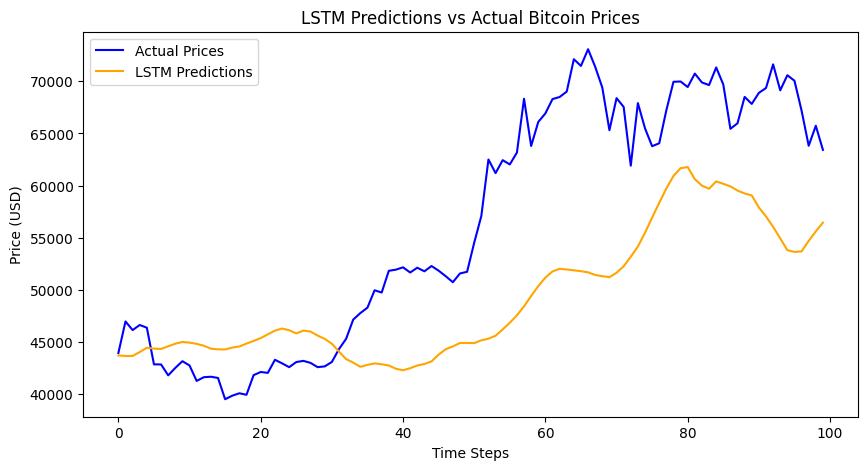

📊 Visualization complete.


In [ ]:
# ==============================================================
# STEP 8: COMPARE MODELS & VISUALIZE RESULTS
# ==============================================================
# WHAT: Compare all models (Linear Regression, ARIMA, LSTM) using error metrics.
# WHY: Lower MAE/RMSE → better predictive accuracy.

results = pd.DataFrame({
    'Model': ['Linear Regression', 'ARIMA', 'LSTM'],
    'MAE': [mae_lr, mae_arima, mae_lstm],
    'RMSE': [rmse_lr, rmse_arima, rmse_lstm]
})

print("✅ Model Comparison Summary:")
print(results)

# Plot LSTM predictions vs actual prices
plt.figure(figsize=(10,5))
plt.plot(y_test[:100], label='Actual Prices', color='blue')
plt.plot(y_pred_lstm[:100], label='LSTM Predictions', color='orange')
plt.title('LSTM Predictions vs Actual Bitcoin Prices')
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

print("📊 Visualization complete.")
